In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving IRIS.csv to IRIS.csv


In [ ]:
# load data
df = pd.read_csv('IRIS.csv')
# df.drop(columns=['Id'], inplace=True) # The 'Id' column was not found, so this line is commented out.
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
df.drop('species', axis=1)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
df.isna().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [ ]:
df.shape

(150, 5)

In [ ]:
# descriptive statistics
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


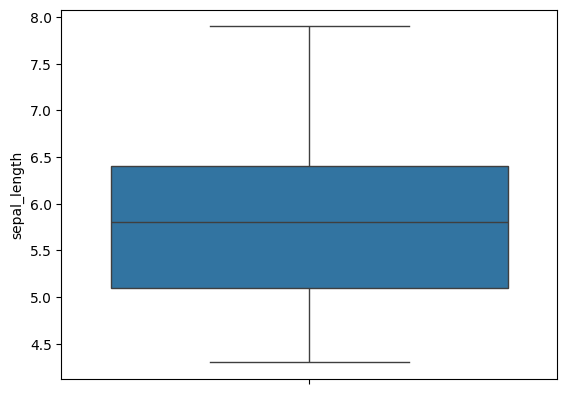

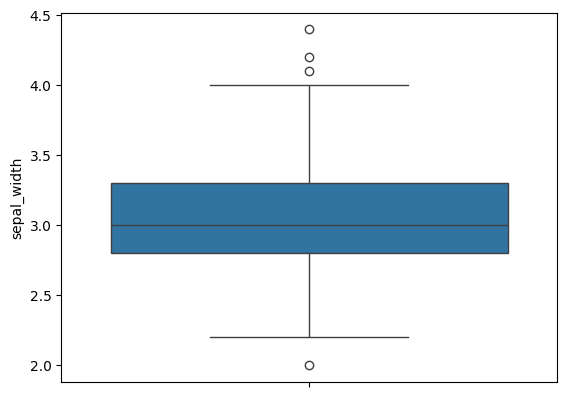

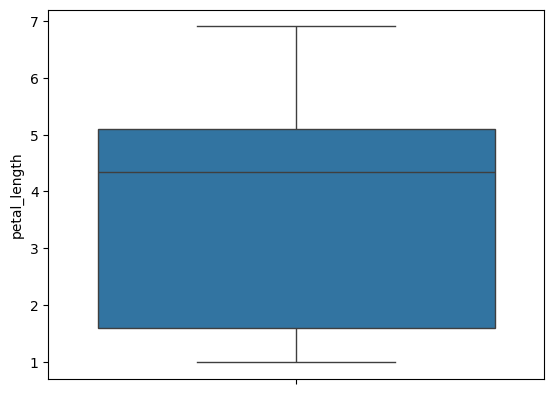

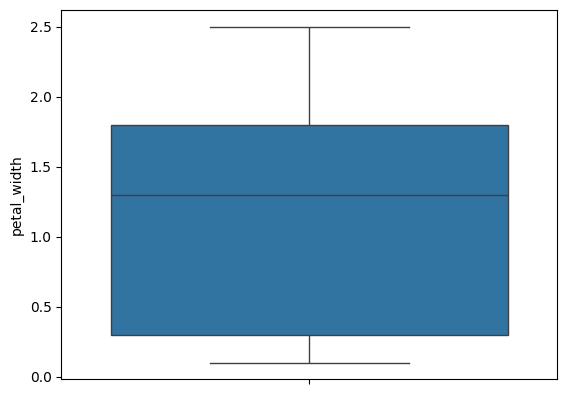

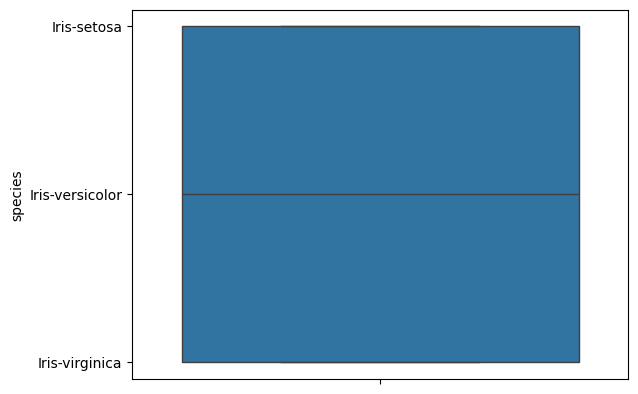

In [ ]:
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()

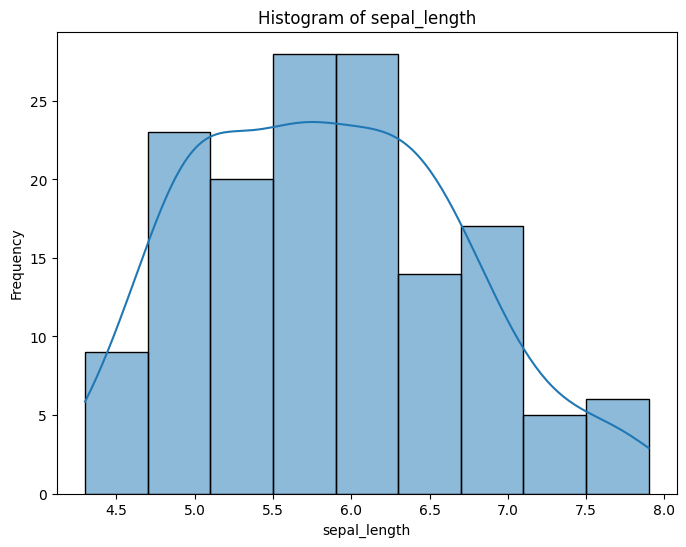

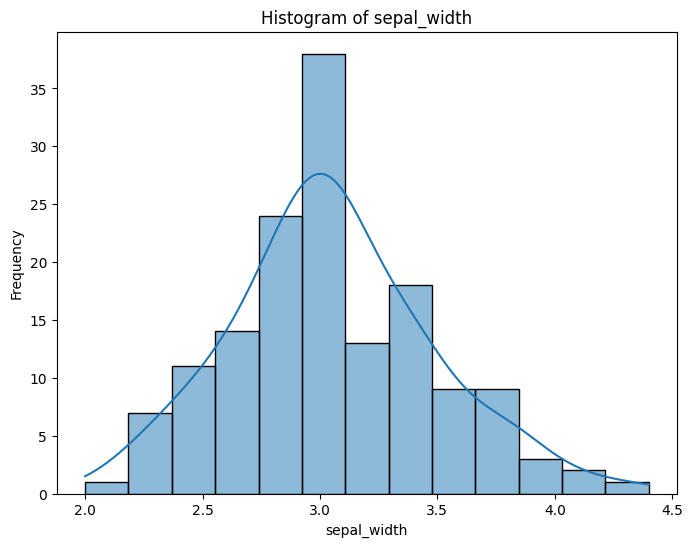

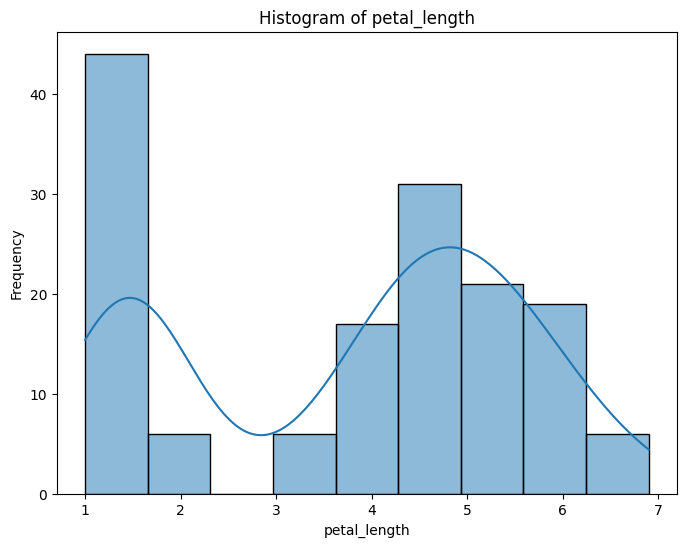

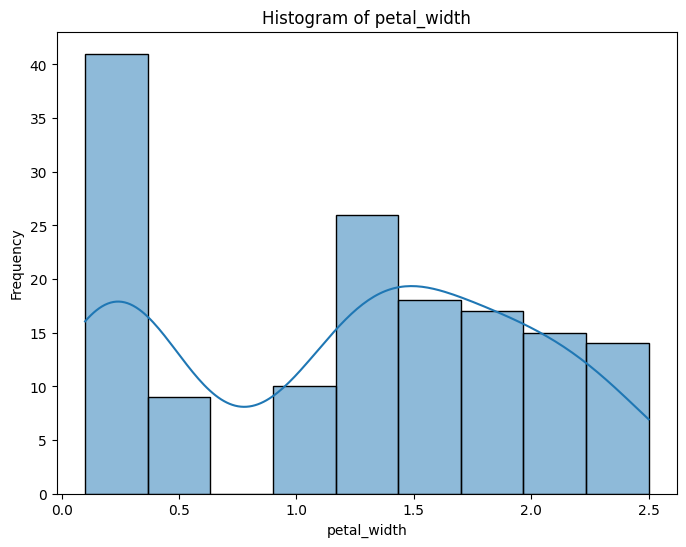

Skipping histogram for non-numeric column: species


In [ ]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        plt.figure(figsize=(8, 6))
        sns.histplot(df[col], kde=True)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()
    else:
        print(f"Skipping histogram for non-numeric column: {col}")

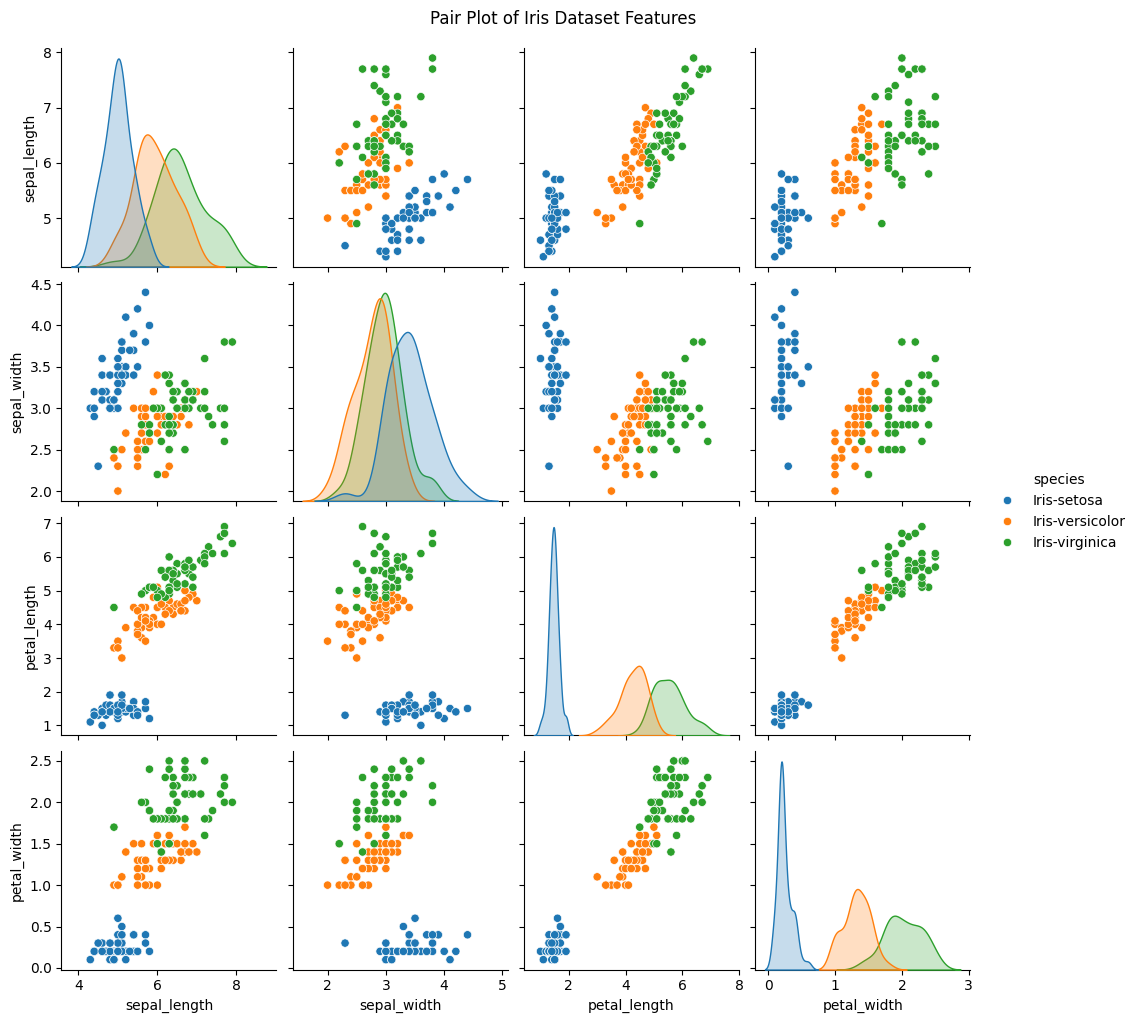

In [ ]:
# Create a pair plot for the DataFrame
# The 'species' column can be used to color-code the points for better insights into class separation
sns.pairplot(df, hue='species')
plt.suptitle('Pair Plot of Iris Dataset Features', y=1.02) # Add a title above the subplots
plt.show()

/tmp/ipykernel_3023/2560227899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, palette='viridis')


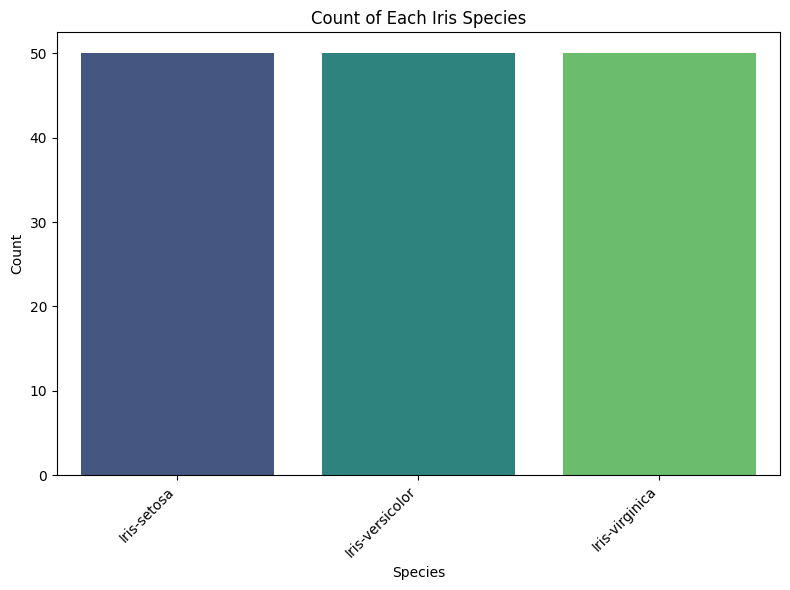

In [ ]:
# Create a bar chart showing the count of each species
plt.figure(figsize=(8, 6))
sns.countplot(x='species', data=df, palette='viridis')
plt.title('Count of Each Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

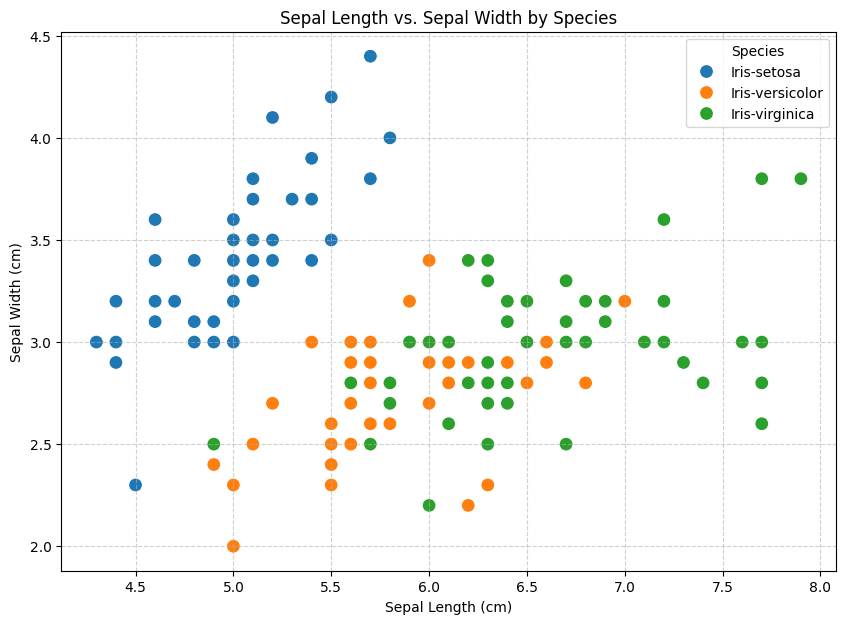

In [ ]:
# Create a scatter plot of sepal length vs. sepal width, colored by species
plt.figure(figsize=(10, 7))
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=df, s=100)
plt.title('Sepal Length vs. Sepal Width by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Define features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

# Encode the target variable 'species' into numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data into training and testing sets
# stratify=y_encoded ensures that the proportion of target classes is roughly the same in the train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# Display the first few rows of X_train and y_train (decoded for clarity)
print("\nX_train head:")
display(X_train.head())
print("\ny_train head (decoded species):")
display(pd.Series(le.inverse_transform(y_train)).head())

Shape of X_train: (120, 4)
Shape of X_test: (30, 4)
Shape of y_train: (120,)
Shape of y_test: (30,)

X_train head:


,sepal_length,sepal_width,petal_length,petal_width
8,4.4,2.9,1.4,0.2
106,4.9,2.5,4.5,1.7
76,6.8,2.8,4.8,1.4
9,4.9,3.1,1.5,0.1
89,5.5,2.5,4.0,1.3



y_train head (decoded species):


,0
0,Iris-setosa
1,Iris-virginica
2,Iris-versicolor
3,Iris-setosa
4,Iris-versicolor


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the KNN classifier
# A common choice for n_neighbors in the Iris dataset is 3 or 5
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.inverse_transform(knn.classes_)))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
 [[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Logistic Regression model
# You can adjust parameters like 'solver' and 'max_iter' if needed
log_reg = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good default for small datasets

# Train the model
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate the model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_log_reg, target_names=le.inverse_transform(log_reg.classes_)))
print("\nLogistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg))

Logistic Regression Accuracy: 0.9666666666666667

Logistic Regression Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


Logistic Regression Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Decision Tree Classifier
# You can adjust parameters like 'criterion', 'max_depth', 'min_samples_leaf', etc.
dtree = DecisionTreeClassifier(random_state=42)

# Train the model
dtree.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dtree = dtree.predict(X_test)

# Evaluate the model
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dtree))
print("\nDecision Tree Classification Report:\n", classification_report(y_test, y_pred_dtree, target_names=le.inverse_transform(dtree.classes_)))
print("\nDecision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dtree))

Decision Tree Accuracy: 0.9333333333333333

Decision Tree Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


Decision Tree Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

for model in [knn, log_reg, dtree]: # Corrected variable names here
    y_pred = model.predict(X_test)
    print(type(model).__name__)
    print(classification_report(y_test, y_pred, target_names=le.inverse_transform(model.classes_))) # Added target_names for clarity
    print(confusion_matrix(y_test, y_pred))
    print('---')

KNeighborsClassifier
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
---
LogisticRegression
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
---
DecisionTreeClassifier
                 precision    recall  f1-score   su

In [ ]:
import joblib

best_model = log_reg  # Corrected variable name from 'logreg' to 'log_reg'
joblib.dump(best_model, 'model.pkl')

['model.pkl']

In [ ]:
import pandas as pd
import joblib

model = joblib.load("model.pkl")

sample = pd.DataFrame([[5.1,3.5,1.4,0.2]],
columns=['sepal_length','sepal_width','petal_length','petal_width']) # Corrected column names to match training data

prediction = model.predict(sample)

print("Predicted species:", prediction)

Predicted species: [0]


# Iris Classification

## Dataset
Iris flower dataset with sepal and petal measurements.

## Models
- k-NN (k=5)
- Logistic Regression
- Decision Tree

## Metrics
Accuracy, precision/recall, confusion matrices for each.

## Usage
1) Install requirements: `pip install -r requirements.txt`
2) Load model:
   ```python
   import joblib
   model = joblib.load('model.pkl')